**Here we are looking at **IS DEMAND VOLATILE BY REGION****

## 03 — Region & Location Volatility
**Project:** Supply Chain DI Engine  
**Question:** Where is the risk happening geographically?  

**Objective:**  
In Notebook 02, we confirmed our products are inherently stable. Now, we slice that same demand by **Location** to see if specific warehouses are facing more uncertainty than others.  

**Key Decision Metrics:**  
1. **Regional CV:** Which warehouse is hardest to plan for?  
2. **The SKU-Region Intersection:** Which specific product-location pairs are "at risk"?  
3. **The Spike Verification:** Identify exactly which region is absorbing the artificial demand shock.

In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Connect to DuckDB
con = duckdb.connect(database=':memory:')

# 2. Register CSV as a table
con.execute("CREATE VIEW demand_history AS SELECT * FROM read_csv_auto('../data/demand_history.csv')")

print("SQL environment ready for Regional Analysis.")

SQL environment ready for Regional Analysis.


Before we look at the SKUs, we need to know which **Market** is the messiest

In [2]:
#We will compute volatility per region (aggregating all SKUs together per week)

region_summary = con.sql("""
    WITH regional_weekly AS (
        SELECT 
            region, 
            date, 
            SUM(demand_units) as total_weekly_demand
        FROM demand_history
        GROUP BY region, date
    )
    SELECT 
        region,
        ROUND(AVG(total_weekly_demand), 2) as avg_weekly_demand,
        ROUND(STDDEV(total_weekly_demand), 2) as std_dev,
        ROUND(STDDEV(total_weekly_demand) / AVG(total_weekly_demand), 4) as region_cv
    FROM regional_weekly
    GROUP BY region
    ORDER BY region_cv DESC
""").df()

display(region_summary)

,region,avg_weekly_demand,std_dev,region_cv
0,East,28450.04,3309.15,0.1163
1,West,24211.36,2326.54,0.0961
2,Central,22610.06,2021.21,0.0894


### Regional Volatility Findings

#### Objective
Determine whether demand uncertainty is concentrated in specific geographic markets.

#### Results

Region	CV
East	0.1163
West	0.0961
Central	0.0894

### Interpretation

All three regions exhibit relatively low volatility, with CV values well below the 0.20 threshold for highly stable demand.

However, important differences exist:

East has the highest regional volatility (CV = 0.1163).
West has moderate volatility (CV = 0.0961).
Central is the most stable region (CV = 0.0894).
Although East remains a stable market overall, its volatility is approximately 30% higher than Central's, indicating greater uncertainty in demand planning.

We have seen that the East is more volatile despite being stable and under 0.2 Cv, but now we **visualize** the three regions on one timeline.

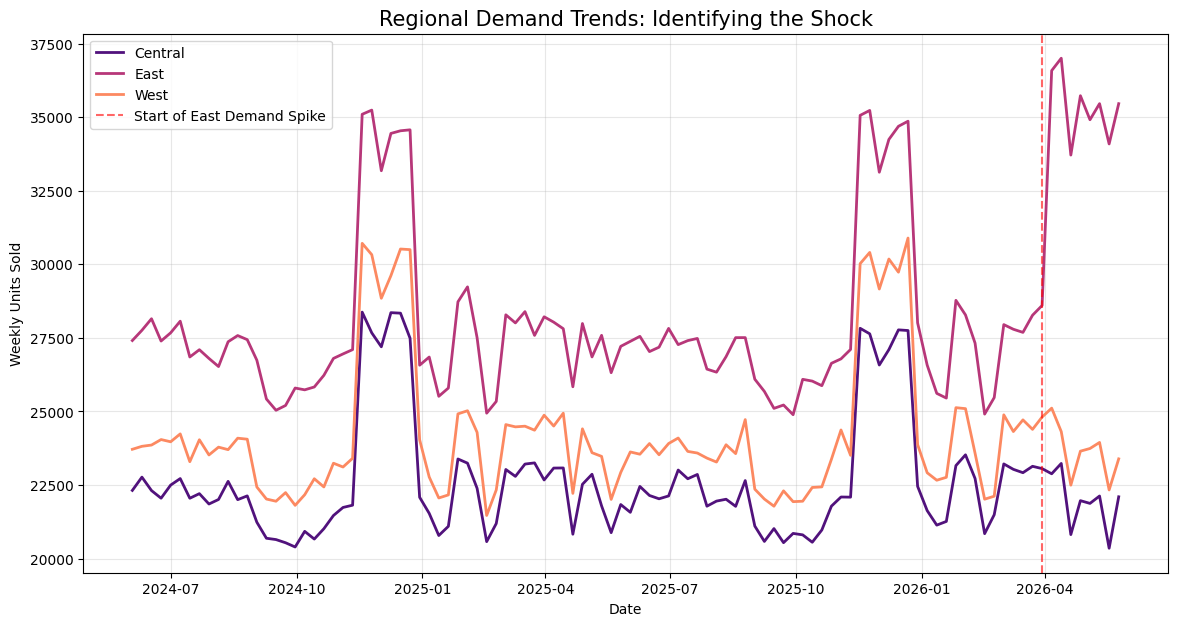

In [3]:
# Aggregate demand by week and region
regional_trends = con.sql("""
    SELECT 
        region, 
        date, 
        SUM(demand_units) as total_demand
    FROM demand_history
    GROUP BY region, date
    ORDER BY date, region
""").df()

# Plotting the pulse of the regions
plt.figure(figsize=(14, 7))
sns.lineplot(data=regional_trends, x='date', y='total_demand', hue='region', palette='magma', linewidth=2)

# Mark the start of the "Uncertainty Spike" (last 8 weeks)
spike_start = regional_trends['date'].max() - pd.Timedelta(weeks=8)
plt.axvline(spike_start, color='red', linestyle='--', alpha=0.6, label='Start of East Demand Spike')

plt.title('Regional Demand Trends: Identifying the Shock', fontsize=15)
plt.ylabel('Weekly Units Sold')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Even though our products are stable (Notebook 02), and our regions are generally well-behaved (Notebook 03), the East Region is currently experiencing a structural demand surge. If we continue allocating inventory based on 'historical averages' from 2024 or 2025, we will run out of stock in the East within weeks.**